In [4]:
import numpy as np
from qlearning import QLearningAgent, softmax

In [5]:
def run_simulation(alpha_true, beta_true, num_trials):
    """
    実際にエージェントを走らせ、データを生成させるための関数
    """
    reward_probabilities = [0.7, 0.3]   # 報酬の確率分布

    # インスタンス化
    agent = QLearningAgent(alpha=alpha_true, beta=beta_true)

    # 行動と報酬の履歴を保存するためのリストを用意
    history_actions = []
    history_rewards = []

    for t in range(num_trials):
        action = agent.choose_action()

        reward = 1 if np.random.rand() < reward_probabilities[action] else 0

        agent.update_q_value(action, reward)

        history_actions.append(action)
        history_rewards.append(reward)
    
    return history_actions, history_rewards

In [6]:
def calculate_log_likelihood(alpha, beta, history_actions, history_rewards):
    """
    仮説のパラメータが観測データにどれくらい当てはまるのかを計算する
    """
    # 1. 評価したい仮説のパラメータでエージェントをインスタンス化する
    agent = QLearningAgent(alpha=alpha, beta=beta)
    
    log_likelihood = 0.0    # 対数尤度の初期値

    # 2. 観測されたデータを1試行目から順番になぞっていく
    for action, reward in zip(history_actions, history_rewards):
        probabilities = softmax(agent.q_values, agent.beta)

        # 実際にデータ上で選ばれていた行動（action）が選ばれる確率を取り出す
        prob_of_chosen_action = probabilities[action]

        # 確率の対数をとって足し合わせる（対数尤度）
        log_likelihood += np.log(prob_of_chosen_action + 1e-8)

        # 価値更新
        # 実際にrewardを使って価値を更新する
        agent.update_q_value(action, reward)
    
    return log_likelihood

In [11]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "MS Gothic"

def visualize_likelihood_surface(num_trials, participants):
    """
    指定した試行数でデータを生成し、尤度の分布を描画する
    """
    # 1. 真のパラメータ（本来のエージェントの個性）を設定してデータを生成
    true_alpha = 0.3
    true_beta = 2.0
    participants = participants
    print(f"--- 参加者 {participants} 人、試行数は各人 {num_trials} 回でシミュレーション開始")

    actions_data = []
    rewards_data = []

    for participant in range(participants):
        actions, rewards = run_simulation(true_alpha, true_beta, num_trials)
        actions_data.append(actions)
        rewards_data.append(rewards)
    
    actions = np.stack([actions_data[x] for x in range(len(actions_data))])
    rewards = np.stack([rewards_data[x] for x in range(len(rewards_data))])

    # 2. 探査するパラメータの範囲を設定
    # alphaは0.01~0.99, betaは0.1~5.0の間で、それぞれ50分割して調べる
    alpha_candidates = np.linspace(0.01, 0.99, 50)
    beta_candidates = np.linspace(0.1, 5.0, 50)

    # 全員分の最尤推定値を書き留めるための空のメモ帳（リスト）を用意
    estimated_alphas = []
    estimated_betas = []

    # 各参加者ごとに独立して推定を行う
    for participant in range(participants):
        likelihoods = np.zeros((len(alpha_candidates), len(beta_candidates)))

        for i, a in enumerate(alpha_candidates):
            for j, b in enumerate(beta_candidates):
                log_likelihood = calculate_log_likelihood(a, b, actions[participant], rewards[participant])
                likelihoods[i, j] = log_likelihood
        
        # 参加者の尤度のうち最も高い場所を探す
        max_idx = np.unravel_index(np.argmax(likelihoods), likelihoods.shape)
        best_alpha = alpha_candidates[max_idx[0]]
        best_beta = beta_candidates[max_idx[1]]

        # 見つけたピークの数値をメモ帳に記録する
        estimated_alphas.append(best_alpha)
        estimated_betas.append(best_beta)
        print(f"参加者 {participant} の推定値：Alpha={best_alpha:.2f}, Beta={best_beta:.2f}")
    
    # 4. 結果を散布図として描画（ピークのばらつきの可視化）
    plt.figure(figsize=(8, 6))

    # 各参加者の推定値を青い点でプロット（alpha=0.6で少し半透明にする）
    plt.scatter(estimated_betas, estimated_alphas, c='blue', alpha=0.6, label="Estimated（各参加者の推定値）")

    # 真のパラメータを赤い星でプロット
    plt.plot(true_beta, true_alpha, 'r*', markersize=15, label='True Parameter（真値）')

    plt.xlabel('Beta（逆温度）')
    plt.ylabel('Alpha（学習率）')
    plt.title(f"Parameter Recovery Scatter Plot (Trials: {num_trials}, N: {participants})")

    # グラフの表示範囲を固定（端っこに張り付く様子を見やすくするため）
    plt.xlim(0, 5.2)
    plt.ylim(0, 1.0)

    plt.legend()
    plt.grid(True)
    plt.show()

--- 参加者 100 人、試行数は各人 50 回でシミュレーション開始
参加者 0 の推定値：Alpha=0.11, Beta=2.40
参加者 1 の推定値：Alpha=0.25, Beta=1.90
参加者 2 の推定値：Alpha=0.55, Beta=2.70
参加者 3 の推定値：Alpha=0.05, Beta=4.50
参加者 4 の推定値：Alpha=0.65, Beta=2.70
参加者 5 の推定値：Alpha=0.23, Beta=1.70
参加者 6 の推定値：Alpha=0.99, Beta=1.40
参加者 7 の推定値：Alpha=0.37, Beta=2.40
参加者 8 の推定値：Alpha=0.49, Beta=0.90
参加者 9 の推定値：Alpha=0.39, Beta=1.50
参加者 10 の推定値：Alpha=0.25, Beta=2.10
参加者 11 の推定値：Alpha=0.47, Beta=1.90
参加者 12 の推定値：Alpha=0.09, Beta=2.10
参加者 13 の推定値：Alpha=0.13, Beta=3.30
参加者 14 の推定値：Alpha=0.07, Beta=3.40
参加者 15 の推定値：Alpha=0.19, Beta=3.20
参加者 16 の推定値：Alpha=0.33, Beta=2.10
参加者 17 の推定値：Alpha=0.43, Beta=2.30
参加者 18 の推定値：Alpha=0.25, Beta=3.40
参加者 19 の推定値：Alpha=0.21, Beta=2.70
参加者 20 の推定値：Alpha=0.03, Beta=3.90
参加者 21 の推定値：Alpha=0.83, Beta=2.50
参加者 22 の推定値：Alpha=0.59, Beta=1.20
参加者 23 の推定値：Alpha=0.05, Beta=3.40
参加者 24 の推定値：Alpha=0.59, Beta=1.20
参加者 25 の推定値：Alpha=0.35, Beta=2.50
参加者 26 の推定値：Alpha=0.67, Beta=1.70
参加者 27 の推定値：Alpha=0.33, Beta=1.50
参加者 28 の推定値：Alpha=0.1

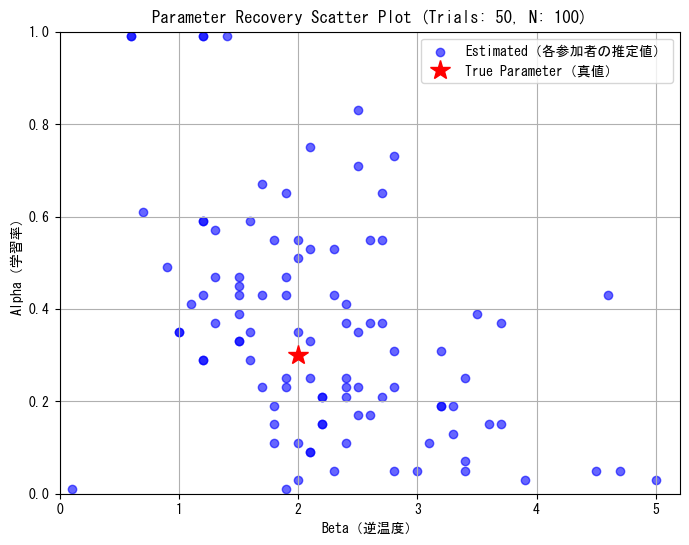

--- 参加者 10 人、試行数は各人 50 回でシミュレーション開始
参加者 0 の推定値：Alpha=0.39, Beta=2.70
参加者 1 の推定値：Alpha=0.45, Beta=1.00
参加者 2 の推定値：Alpha=0.37, Beta=1.50
参加者 3 の推定値：Alpha=0.09, Beta=3.50
参加者 4 の推定値：Alpha=0.61, Beta=1.60
参加者 5 の推定値：Alpha=0.41, Beta=0.90
参加者 6 の推定値：Alpha=0.37, Beta=0.80
参加者 7 の推定値：Alpha=0.19, Beta=2.90
参加者 8 の推定値：Alpha=0.15, Beta=2.20
参加者 9 の推定値：Alpha=0.21, Beta=2.30


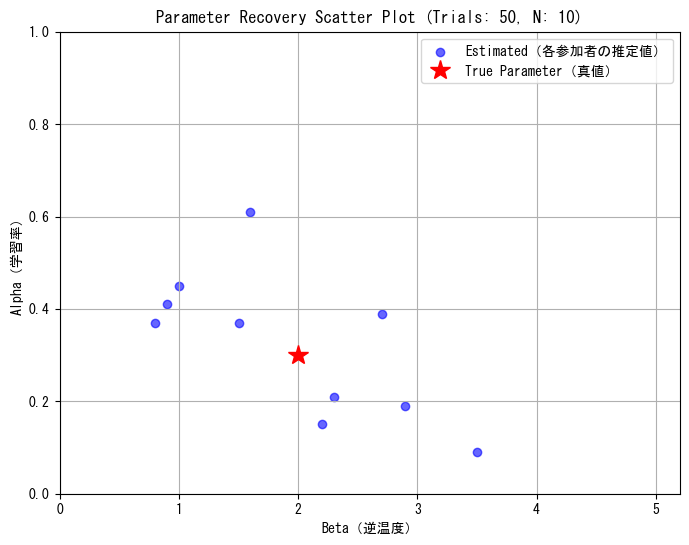

In [12]:
# 実験開始！

# 試行数はどちらも50回で固定する

# パターンA：参加者が十分にある（信頼できるデータ）場合
visualize_likelihood_surface(num_trials=50, participants=100)

# パターンB：参加者が少なく、ノイズに弱い場合
visualize_likelihood_surface(num_trials=50, participants=10)